# Group 8 - ANN Lab 3

This notebook answers all required items in one file:
1. Hyperparameter tuning of `ImageDataGenerator`. Assigned: Abelardo, Aasen Sofia P.
2. VGG19 implementation and comparison with VGG16. Assigned: Gumban, Joevanni Paulo T.
3. VGG16 test accuracy vs training sample sizes `[500, 1000, 2000, 5000, 10000, 15000]` (no augmentation, 30 epochs/run). Assigned: Aquino, Matthew Benedict U.
4. Xception (Extreme Inception) implementation and comparison with VGG models. Assigned: Balingit, Den Mar F.

In [51]:
import os
import random
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import Markdown, display
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications import VGG16, VGG19, Xception

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_DATASET_DIR = DATA_DIR / 'cats_and_dogs_from_petimages'
WORKING_SPLIT_DIR = DATA_DIR / 'working_split_for_lab3'

print('TensorFlow version:', tf.__version__)
print('Project directory:', PROJECT_DIR)
print('Base dataset:', BASE_DATASET_DIR)
print('Output directory:', OUTPUT_DIR)

TensorFlow version: 2.21.0
Project directory: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks
Base dataset: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/data/cats_and_dogs_from_petimages
Output directory: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models


In [52]:
def count_split(split_dir: Path):
    counts = {}
    total = 0
    for cls in ['cats', 'dogs']:
        cls_dir = split_dir / cls
        n = len(list(cls_dir.glob('*'))) if cls_dir.exists() else 0
        counts[cls] = n
        total += n
    counts['total'] = total
    return counts


def print_split_table(title, split_map):
    rows = []
    for split_name, split_dir in split_map.items():
        c = count_split(split_dir)
        rows.append({
            'split': split_name,
            'cats': c['cats'],
            'dogs': c['dogs'],
            'total': c['total'],
            'path': str(split_dir)
        })
    df = pd.DataFrame(rows)
    print(f'\n{title}')
    display(df)
    return df


source_train = BASE_DATASET_DIR / 'train'
source_val = BASE_DATASET_DIR / 'validation'
source_test = BASE_DATASET_DIR / 'test'

if source_test.exists():
    train_dir = source_train
    validation_dir = source_val
    test_dir = source_test
    split_note = 'Using dataset-provided train/validation/test directories.'
else:
    if WORKING_SPLIT_DIR.exists():
        shutil.rmtree(WORKING_SPLIT_DIR)

    for split in ['train', 'validation', 'test']:
        for cls in ['cats', 'dogs']:
            (WORKING_SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

    for cls in ['cats', 'dogs']:
        src_cls = source_train / cls
        dst_cls = WORKING_SPLIT_DIR / 'train' / cls
        for f in src_cls.iterdir():
            if f.is_file():
                shutil.copy2(f, dst_cls / f.name)

    for cls in ['cats', 'dogs']:
        src_cls = source_val / cls
        files = [f for f in src_cls.iterdir() if f.is_file()]
        files.sort(key=lambda p: p.name)
        rng = random.Random(SEED)
        rng.shuffle(files)

        half = len(files) // 2
        val_files = files[:half]
        test_files = files[half:]

        for f in val_files:
            shutil.copy2(f, WORKING_SPLIT_DIR / 'validation' / cls / f.name)
        for f in test_files:
            shutil.copy2(f, WORKING_SPLIT_DIR / 'test' / cls / f.name)

    train_dir = WORKING_SPLIT_DIR / 'train'
    validation_dir = WORKING_SPLIT_DIR / 'validation'
    test_dir = WORKING_SPLIT_DIR / 'test'
    split_note = (
        'No dataset-provided test directory was found. Created disjoint validation/test '
        'splits from the provided validation set (500 val + 500 test total).'
    )

print(split_note)
split_df = print_split_table(
    'Dataset split used by this notebook:',
    {'train': train_dir, 'validation': validation_dir, 'test': test_dir}
)

required = {'train': 2000, 'validation': 1000, 'test': 1000}
actual = {r['split']: int(r['total']) for _, r in split_df.iterrows()}
print('Required totals:', required)
print('Actual totals:  ', actual)
if actual != required:
    print(
        '\nNOTE: Current local dataset does not exactly match the required 2000/1000/1000 split. '
        'Results remain valid for this available split, and all comparisons use the same split.'
    )

No dataset-provided test directory was found. Created disjoint validation/test splits from the provided validation set (500 val + 500 test total).

Dataset split used by this notebook:


,split,cats,dogs,total,path
0,train,1000,1000,2000,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,validation,250,250,500,/home/solyvie/workspace/cs-projects/25263CSDMa...
2,test,250,250,500,/home/solyvie/workspace/cs-projects/25263CSDMa...


Required totals: {'train': 2000, 'validation': 1000, 'test': 1000}
Actual totals:   {'train': 2000, 'validation': 500, 'test': 500}

NOTE: Current local dataset does not exactly match the required 2000/1000/1000 split. Results remain valid for this available split, and all comparisons use the same split.


In [53]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 20


def make_generators(train_aug_kwargs, batch_size=BATCH_SIZE):
    train_datagen = ImageDataGenerator(**train_aug_kwargs)
    eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_datagen.flow_from_directory(
        str(train_dir),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True,
        seed=SEED,
    )

    val_gen = eval_datagen.flow_from_directory(
        str(validation_dir),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False,
    )

    test_gen = eval_datagen.flow_from_directory(
        str(test_dir),
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


def build_transfer_model(backbone_name='VGG16'):
    if backbone_name == 'VGG16':
        conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
        pooling = 'flatten'
    elif backbone_name == 'VGG19':
        conv_base = VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
        pooling = 'flatten'
    elif backbone_name == 'Xception':
        conv_base = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
        pooling = 'gap'
    else:
        raise ValueError(f'Unsupported backbone: {backbone_name}')

    conv_base.trainable = False

    model = models.Sequential(name=f'{backbone_name}_transfer')
    model.add(conv_base)
    if pooling == 'flatten':
        model.add(layers.Flatten())
    else:
        model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizers.RMSprop(learning_rate=2e-5),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    return model


def save_h5(model, model_name):
    model_path = OUTPUT_DIR / f'{model_name}.h5'
    model.save(str(model_path))
    return model_path


def plot_history(history, title):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs = list(range(1, len(acc) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, acc, label='Train Accuracy')
    axes[0].plot(epochs, val_acc, label='Validation Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, loss, label='Train Loss')
    axes[1].plot(epochs, val_loss, label='Validation Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def train_eval_save(
    model_name,
    backbone_name,
    train_aug_kwargs,
    epochs=30,
    batch_size=BATCH_SIZE,
    early_stopping=True,
    steps_per_epoch=None,
    verbose=1,
):
    train_gen, val_gen, test_gen = make_generators(train_aug_kwargs, batch_size=batch_size)

    model = build_transfer_model(backbone_name)

    callbacks = []
    if early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True,
                verbose=1,
            )
        )

    start = time.time()
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=callbacks,
        steps_per_epoch=steps_per_epoch,
        verbose=verbose,
    )
    train_time = time.time() - start

    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)

    model_path = save_h5(model, model_name)

    result = {
        'model_name': model_name,
        'backbone': backbone_name,
        'epochs_ran': len(history.history['accuracy']),
        'best_val_acc_during_train': float(max(history.history['val_accuracy'])),
        'final_train_acc': float(history.history['accuracy'][-1]),
        'final_val_acc': float(val_acc),
        'final_test_acc': float(test_acc),
        'train_time_sec': float(train_time),
        'model_h5_path': str(model_path),
        'history': history,
        'model_obj': model,
    }

    return result

## 1) Improve Model via `ImageDataGenerator` Hyperparameters

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777522274.451715   23844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_220068__.62


100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.6230 - loss: 0.6416 - val_accuracy: 0.8240 - val_loss: 0.4599
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.7645 - loss: 0.4927 - val_accuracy: 0.8620 - val_loss: 0.3691
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.8100 - loss: 0.4255 - val_accuracy: 0.8700 - val_loss: 0.3288
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.8235 - loss: 0.3853 - val_accuracy: 0.8740 - val_loss: 0.3073
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.8485 - loss: 0.3568 - val_accuracy: 0.8760 - val_loss: 0.2941
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.8395 - loss: 0.3532 - val_accuracy: 0.8880 - val_loss: 0.2843
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.8565 - loss: 0.3287 - val_accuracy: 0.8700 - val_loss: 0.2950
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.8640 - loss: 0.3158 - val

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777522649.773588   23844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_239558__.62


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.5845 - loss: 0.6929 - val_accuracy: 0.8120 - val_loss: 0.4914
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.6915 - loss: 0.5764 - val_accuracy: 0.8460 - val_loss: 0.4164
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.7315 - loss: 0.5201 - val_accuracy: 0.8520 - val_loss: 0.3677
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.7680 - loss: 0.4722 - val_accuracy: 0.8500 - val_loss: 0.3335
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.7945 - loss: 0.4430 - val_accuracy: 0.8600 - val_loss: 0.3262
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.8030 - loss: 0.4314 - val_accuracy: 0.8540 - val_loss: 0.3159
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.8075 - loss: 0.4251 - val_accuracy: 0.8720 - val_loss: 0.2897
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.8150 - loss: 0.4116 - val

Q1 Results Table


,model_name,epochs_ran,best_val_acc_during_train,final_train_acc,final_val_acc,final_test_acc,train_time_sec,model_h5_path
0,Q1_VGG16_default_aug,30,0.908,0.9085,0.898,0.900,372.180018,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,Q1_VGG16_modified_aug,30,0.906,0.8655,0.898,0.884,408.268546,/home/solyvie/workspace/cs-projects/25263CSDMa...


Best Q1 configuration by test accuracy: Q1_VGG16_default_aug (test_acc=0.9000)


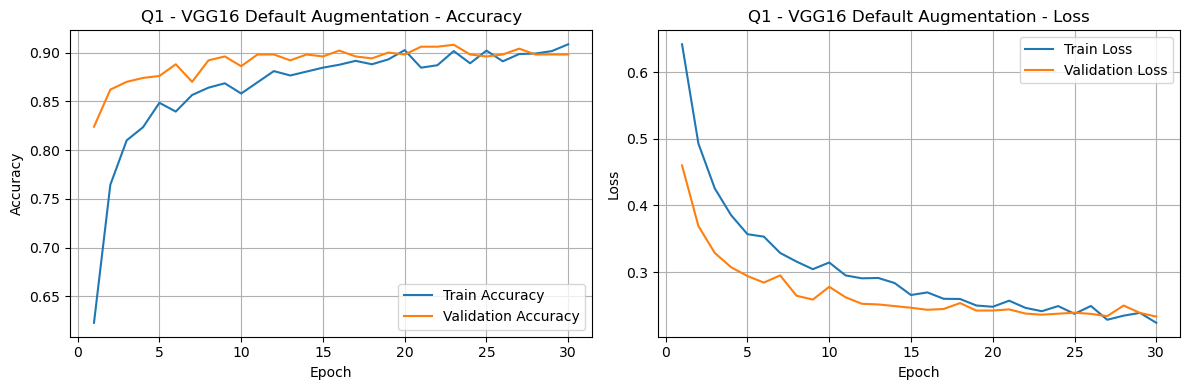

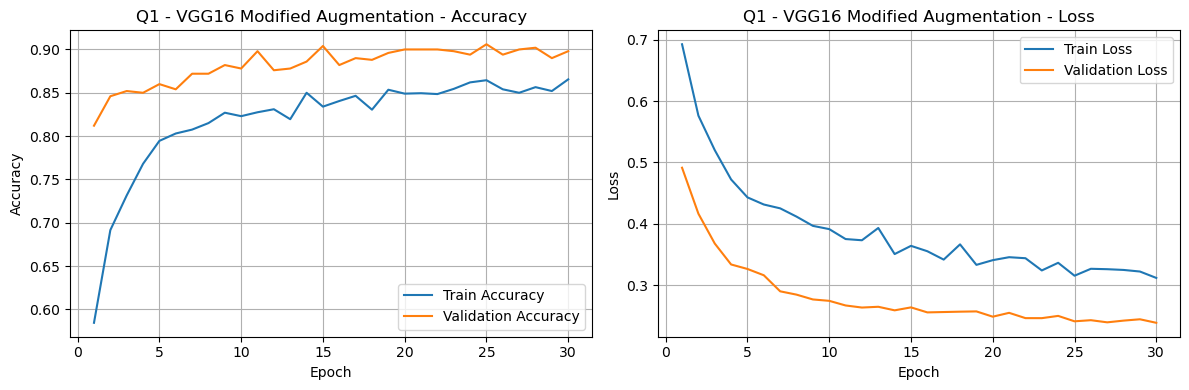

In [54]:
default_aug = {
    'rescale': 1.0 / 255,
    'rotation_range': 20,
    'width_shift_range': 0.10,
    'height_shift_range': 0.10,
    'shear_range': 0.10,
    'zoom_range': 0.10,
    'horizontal_flip': True,
    'fill_mode': 'nearest',
}

modified_aug = {
    'rescale': 1.0 / 255,
    'rotation_range': 35,
    'width_shift_range': 0.20,
    'height_shift_range': 0.20,
    'shear_range': 0.15,
    'zoom_range': 0.20,
    'horizontal_flip': True,
    'brightness_range': (0.85, 1.15),
    'channel_shift_range': 20.0,
    'fill_mode': 'nearest',
}

q1_default = train_eval_save(
    model_name='Q1_VGG16_default_aug',
    backbone_name='VGG16',
    train_aug_kwargs=default_aug,
    epochs=30,
    early_stopping=True,
    verbose=1,
)

q1_modified = train_eval_save(
    model_name='Q1_VGG16_modified_aug',
    backbone_name='VGG16',
    train_aug_kwargs=modified_aug,
    epochs=30,
    early_stopping=True,
    verbose=1,
)

q1_df = pd.DataFrame([
    {k: v for k, v in q1_default.items() if k not in ['history', 'model_obj']},
    {k: v for k, v in q1_modified.items() if k not in ['history', 'model_obj']},
])

q1_display_cols = [
    'model_name', 'epochs_ran', 'best_val_acc_during_train',
    'final_train_acc', 'final_val_acc', 'final_test_acc',
    'train_time_sec', 'model_h5_path'
]

print('Q1 Results Table')
display(q1_df[q1_display_cols].sort_values('final_test_acc', ascending=False).reset_index(drop=True))

q1_best = q1_df.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best Q1 configuration by test accuracy: {q1_best['model_name']} "
    f"(test_acc={q1_best['final_test_acc']:.4f})"
)

plot_history(q1_default['history'], 'Q1 - VGG16 Default Augmentation')
plot_history(q1_modified['history'], 'Q1 - VGG16 Modified Augmentation')

## 2) Implement VGG19 and Compare with VGG16

Both are trained under the same augmentation setup for fair comparison.

Using augmentation for Q2: default_aug
Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777523065.445367   23841 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_259168__.62


100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - accuracy: 0.6510 - loss: 0.6270 - val_accuracy: 0.8300 - val_loss: 0.4425
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.7550 - loss: 0.4939 - val_accuracy: 0.8580 - val_loss: 0.3666
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.8020 - loss: 0.4260 - val_accuracy: 0.8700 - val_loss: 0.3267
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.8215 - loss: 0.3923 - val_accuracy: 0.8760 - val_loss: 0.3066
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.8375 - loss: 0.3743 - val_accuracy: 0.8820 - val_loss: 0.2937
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.8405 - loss: 0.3525 - val_accuracy: 0.8980 - val_loss: 0.2779
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.8460 - loss: 0.3479 - val_accuracy: 0.8900 - val_loss: 0.2718
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.8710 - loss: 0.3251 - val

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777523448.417399   23844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_279150__.65


100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.6145 - loss: 0.6559 - val_accuracy: 0.7920 - val_loss: 0.4996
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.7245 - loss: 0.5387 - val_accuracy: 0.8100 - val_loss: 0.4371
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.7650 - loss: 0.4838 - val_accuracy: 0.8360 - val_loss: 0.3940
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.7935 - loss: 0.4447 - val_accuracy: 0.8360 - val_loss: 0.3723
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.8120 - loss: 0.4096 - val_accuracy: 0.8440 - val_loss: 0.3551
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.8050 - loss: 0.4066 - val_accuracy: 0.8680 - val_loss: 0.3395
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.8280 - loss: 0.3829 - val_accuracy: 0.8620 - val_loss: 0.3341
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.8290 - loss: 0.3824 - val

Q2 Results Table


,model_name,backbone,num_layers,num_params,epochs_ran,final_train_acc,final_val_acc,final_test_acc,train_time_sec,model_h5_path
0,Q2_VGG19,VGG19,22,20024384,30,0.887,0.872,0.910,384.580479,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,Q2_VGG16,VGG16,19,14714688,30,0.903,0.910,0.898,379.770050,/home/solyvie/workspace/cs-projects/25263CSDMa...


Best in Q2 by test accuracy: VGG19 (test_acc=0.9100)


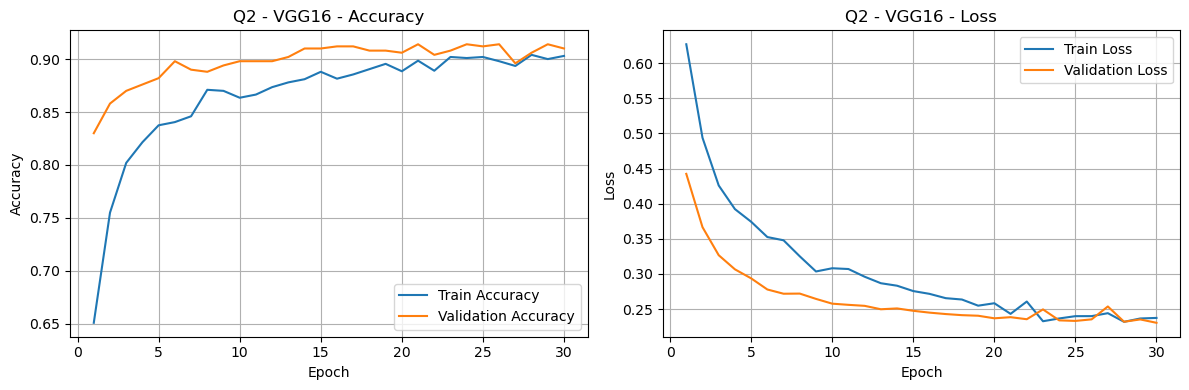

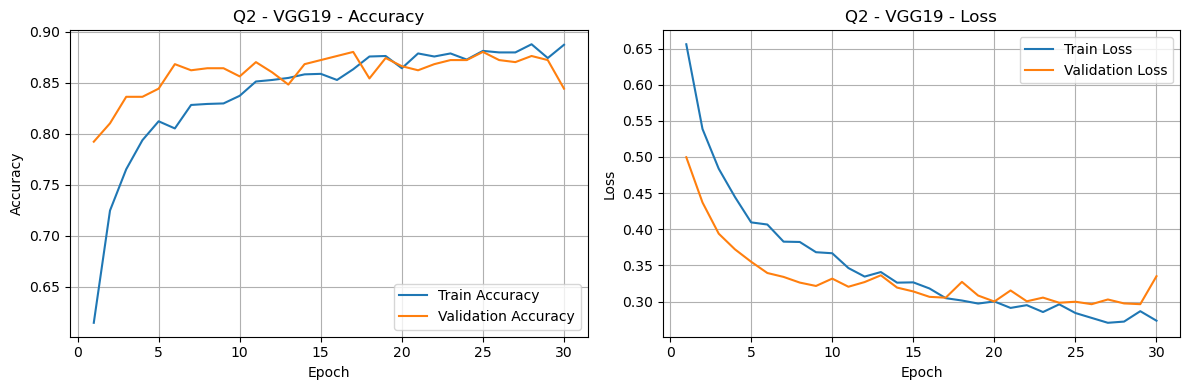

In [55]:
best_aug_name = 'modified_aug' if q1_modified['final_test_acc'] >= q1_default['final_test_acc'] else 'default_aug'
best_aug = modified_aug if best_aug_name == 'modified_aug' else default_aug
print('Using augmentation for Q2:', best_aug_name)

q2_vgg16 = train_eval_save(
    model_name='Q2_VGG16',
    backbone_name='VGG16',
    train_aug_kwargs=best_aug,
    epochs=30,
    early_stopping=True,
    verbose=1,
)

q2_vgg19 = train_eval_save(
    model_name='Q2_VGG19',
    backbone_name='VGG19',
    train_aug_kwargs=best_aug,
    epochs=30,
    early_stopping=True,
    verbose=1,
)

arch_stats = []
for backbone in ['VGG16', 'VGG19']:
    if backbone == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    else:
        base = VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    arch_stats.append({
        'backbone': backbone,
        'num_layers': len(base.layers),
        'num_params': base.count_params(),
    })

arch_df = pd.DataFrame(arch_stats)
q2_df = pd.DataFrame([
    {k: v for k, v in q2_vgg16.items() if k not in ['history', 'model_obj']},
    {k: v for k, v in q2_vgg19.items() if k not in ['history', 'model_obj']},
])
q2_df = q2_df.merge(arch_df, left_on='backbone', right_on='backbone', how='left')

q2_display_cols = [
    'model_name', 'backbone', 'num_layers', 'num_params',
    'epochs_ran', 'final_train_acc', 'final_val_acc', 'final_test_acc',
    'train_time_sec', 'model_h5_path'
]

print('Q2 Results Table')
display(q2_df[q2_display_cols].sort_values('final_test_acc', ascending=False).reset_index(drop=True))

q2_best = q2_df.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best in Q2 by test accuracy: {q2_best['backbone']} "
    f"(test_acc={q2_best['final_test_acc']:.4f})"
)

plot_history(q2_vgg16['history'], 'Q2 - VGG16')
plot_history(q2_vgg19['history'], 'Q2 - VGG19')

## 3) VGG16 Test Accuracy vs Training Samples (No Data Augmentation)

Required sample sizes: `500, 1000, 2000, 5000, 10000, 15000`.
Each run uses **30 epochs**.

`Note:` Q3 training is run with `verbose=0` to suppress epoch logs and keep PDF export compact.

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


I0000 00:00:1777523837.259918   23845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_299564__.62


Restoring model weights from the end of the best epoch: 30.


Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


I0000 00:00:1777523904.687969   23843 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_310422__.62


...

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


I0000 00:00:1777524302.963603   23845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_364433__.62


Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 14.


Q3 Results Table


,samples_per_epoch_target,steps_per_epoch,epochs_ran,final_train_acc,final_val_acc,final_test_acc,train_time_sec,model_h5_path
0,500,25,30,0.8900,0.888,0.888,64.257334,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,1000,50,29,0.9440,0.908,0.896,91.852459,/home/solyvie/workspace/cs-projects/25263CSDMa...
2,2000,100,18,0.9440,0.898,0.902,92.207176,/home/solyvie/workspace/cs-projects/25263CSDMa...
3,5000,250,20,0.9530,0.896,0.898,100.421194,/home/solyvie/workspace/cs-projects/25263CSDMa...
4,10000,500,20,0.9520,0.902,0.900,101.510481,/home/solyvie/workspace/cs-projects/25263CSDMa...
5,15000,750,19,0.9535,0.906,0.890,96.281361,/home/solyvie/workspace/cs-projects/25263CSDMa...


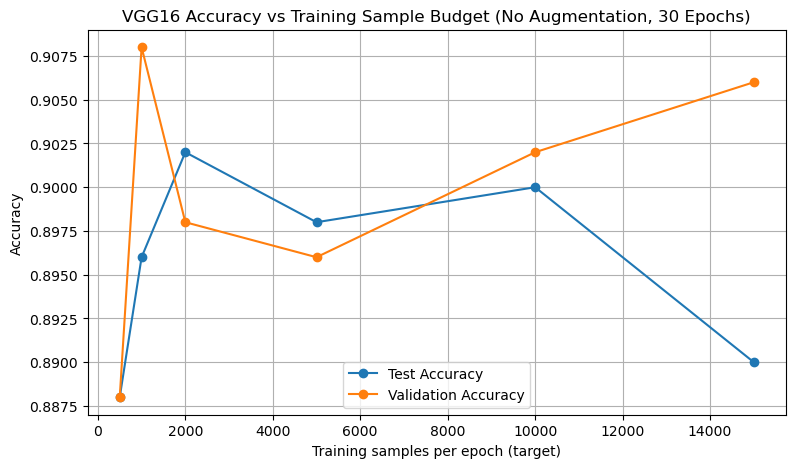

Best Q3 run: 2000 samples/epoch (test_acc=0.9020)


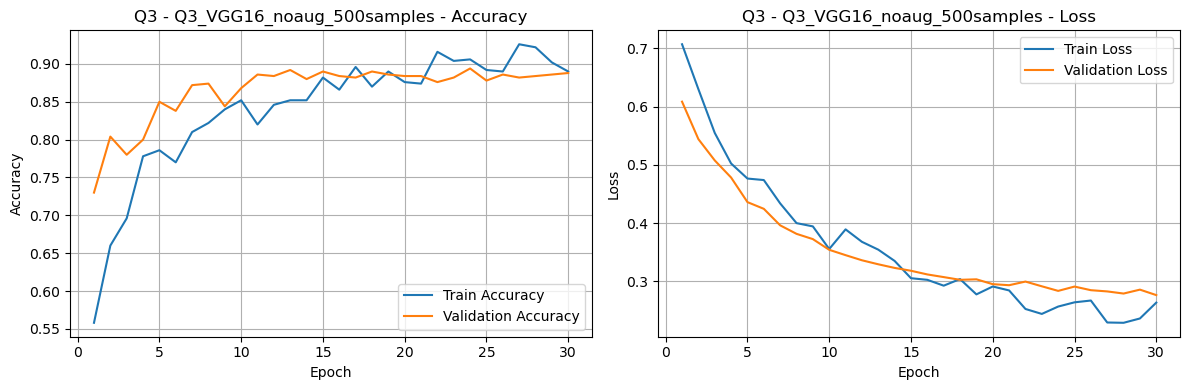

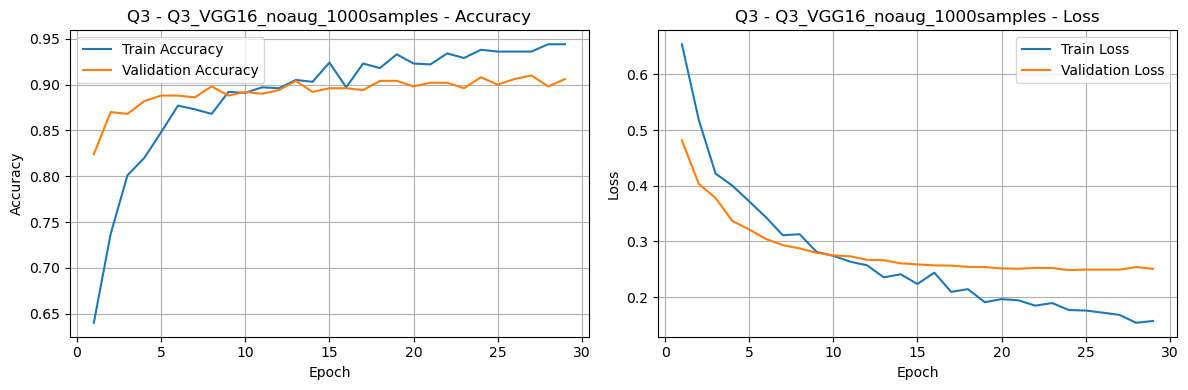

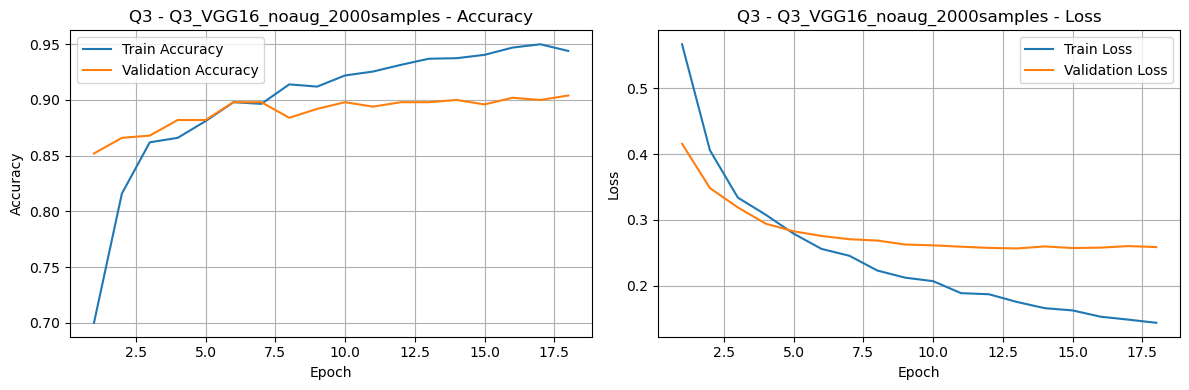

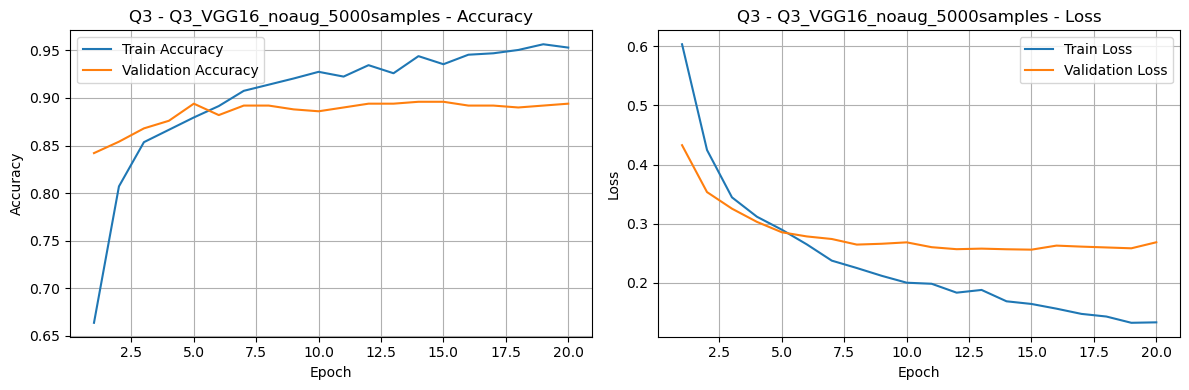

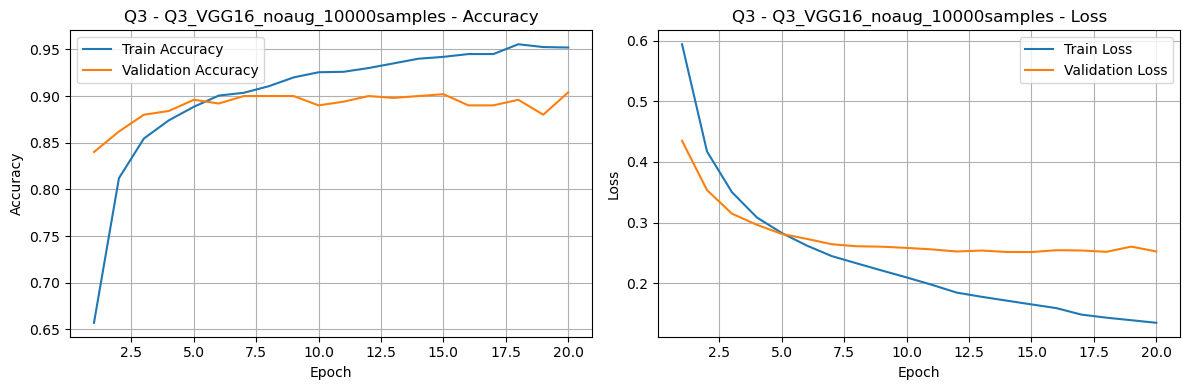

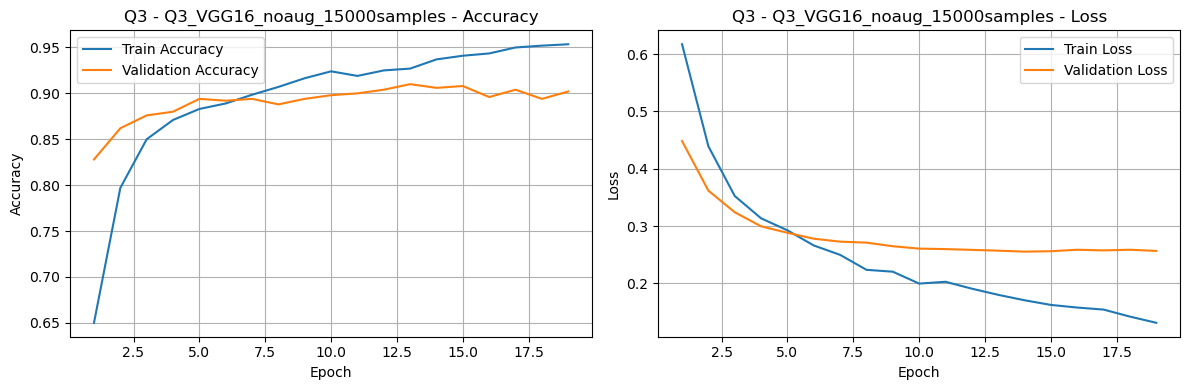

In [56]:
sample_sizes = [500, 1000, 2000, 5000, 10000, 15000]
q3_results = []
q3_full_runs = []

no_aug = {'rescale': 1.0 / 255}

for n_samples in sample_sizes:
    steps = max(1, int(np.ceil(n_samples / BATCH_SIZE)))
    run_name = f'Q3_VGG16_noaug_{n_samples}samples'

    run = train_eval_save(
        model_name=run_name,
        backbone_name='VGG16',
        train_aug_kwargs=no_aug,
        epochs=30,
        early_stopping=True,
        steps_per_epoch=steps,
        verbose=0,
    )

    q3_full_runs.append(run)
    q3_results.append({
        'samples_per_epoch_target': n_samples,
        'steps_per_epoch': steps,
        'epochs_ran': run['epochs_ran'],
        'final_train_acc': run['final_train_acc'],
        'final_val_acc': run['final_val_acc'],
        'final_test_acc': run['final_test_acc'],
        'train_time_sec': run['train_time_sec'],
        'model_h5_path': run['model_h5_path'],
    })

q3_df = pd.DataFrame(q3_results)
print('Q3 Results Table')
display(q3_df)

plt.figure(figsize=(9, 5))
plt.plot(q3_df['samples_per_epoch_target'], q3_df['final_test_acc'], marker='o', label='Test Accuracy')
plt.plot(q3_df['samples_per_epoch_target'], q3_df['final_val_acc'], marker='o', label='Validation Accuracy')
plt.xlabel('Training samples per epoch (target)')
plt.ylabel('Accuracy')
plt.title('VGG16 Accuracy vs Training Sample Budget (No Augmentation, 30 Epochs)')
plt.grid(True)
plt.legend()
plt.show()

best_q3 = q3_df.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best Q3 run: {int(best_q3['samples_per_epoch_target'])} samples/epoch "
    f"(test_acc={best_q3['final_test_acc']:.4f})"
)

for run in q3_full_runs:
    plot_history(run['history'], f"Q3 - {run['model_name']}")

## 4) Implement Xception and Compare Architecture + Accuracy

Uses the same train/validation/test split configured at the start of this notebook.

Found 2000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/30


I0000 00:00:1777524413.493501   23843 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_383626__.123


100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 189ms/step - accuracy: 0.7925 - loss: 0.4639 - val_accuracy: 0.9380 - val_loss: 0.2374
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9045 - loss: 0.2426 - val_accuracy: 0.9520 - val_loss: 0.1513
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.9245 - loss: 0.1956 - val_accuracy: 0.9580 - val_loss: 0.1252
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.9305 - loss: 0.1761 - val_accuracy: 0.9560 - val_loss: 0.1147
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.9460 - loss: 0.1429 - val_accuracy: 0.9580 - val_loss: 0.1066
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.9390 - loss: 0.1455 - val_accuracy: 0.9560 - val_loss: 0.1020
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9435 - loss: 0.1412 - val_accuracy: 0.9560 - val_loss: 0.0996
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9470 - loss: 0.1369 - val

Q4 Comparison Table


,model_type,backbone,num_layers,num_params,final_val_acc,final_test_acc,model_h5_path
0,Xception (Q4),Xception,132,20861480,0.966,0.964,/home/solyvie/workspace/cs-projects/25263CSDMa...
1,Best VGG16/VGG19 from Q2,VGG19,22,20024384,0.872,0.910,/home/solyvie/workspace/cs-projects/25263CSDMa...
2,Best augmentation VGG16 from Q1,VGG16,19,14714688,0.898,0.900,/home/solyvie/workspace/cs-projects/25263CSDMa...


Best overall in Q4 comparison: Xception (test_acc=0.9640)


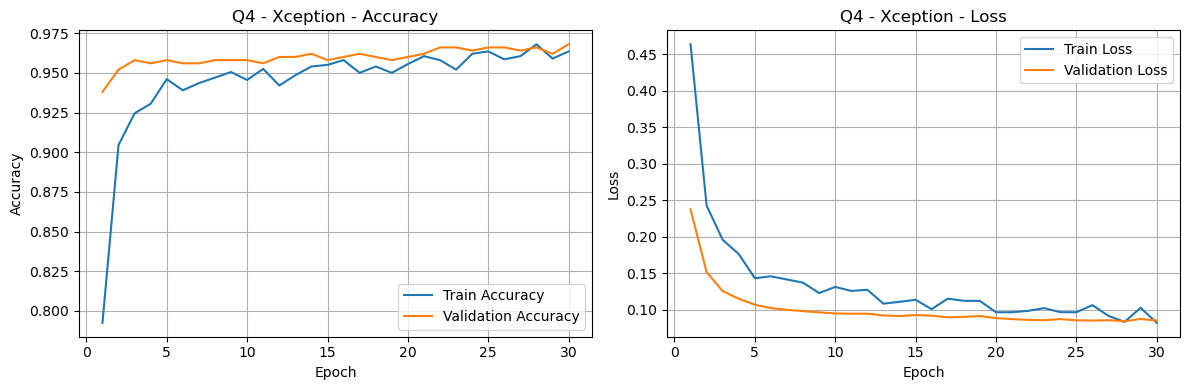

In [57]:
q4_xception = train_eval_save(
    model_name='Q4_Xception',
    backbone_name='Xception',
    train_aug_kwargs=best_aug,
    epochs=30,
    early_stopping=True,
    verbose=1,
)

q1_best_row = q1_df.sort_values('final_test_acc', ascending=False).iloc[0]
q2_best_row = q2_df.sort_values('final_test_acc', ascending=False).iloc[0]

arch_meta = {
    'VGG16': {
        'num_layers': len(VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).layers),
        'num_params': VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).count_params(),
    },
    'VGG19': {
        'num_layers': len(VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).layers),
        'num_params': VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).count_params(),
    },
    'Xception': {
        'num_layers': len(Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).layers),
        'num_params': Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3)).count_params(),
    },
}

q4_compare = pd.DataFrame([
    {
        'model_type': 'Best VGG16/VGG19 from Q2',
        'backbone': q2_best_row['backbone'],
        'num_layers': arch_meta[q2_best_row['backbone']]['num_layers'],
        'num_params': arch_meta[q2_best_row['backbone']]['num_params'],
        'final_val_acc': q2_best_row['final_val_acc'],
        'final_test_acc': q2_best_row['final_test_acc'],
        'model_h5_path': q2_best_row['model_h5_path'],
    },
    {
        'model_type': 'Best augmentation VGG16 from Q1',
        'backbone': 'VGG16',
        'num_layers': arch_meta['VGG16']['num_layers'],
        'num_params': arch_meta['VGG16']['num_params'],
        'final_val_acc': q1_best_row['final_val_acc'],
        'final_test_acc': q1_best_row['final_test_acc'],
        'model_h5_path': q1_best_row['model_h5_path'],
    },
    {
        'model_type': 'Xception (Q4)',
        'backbone': 'Xception',
        'num_layers': arch_meta['Xception']['num_layers'],
        'num_params': arch_meta['Xception']['num_params'],
        'final_val_acc': q4_xception['final_val_acc'],
        'final_test_acc': q4_xception['final_test_acc'],
        'model_h5_path': q4_xception['model_h5_path'],
    },
])

print('Q4 Comparison Table')
display(q4_compare.sort_values('final_test_acc', ascending=False).reset_index(drop=True))

q4_best = q4_compare.sort_values('final_test_acc', ascending=False).iloc[0]
print(
    f"Best overall in Q4 comparison: {q4_best['backbone']} "
    f"(test_acc={q4_best['final_test_acc']:.4f})"
)

plot_history(q4_xception['history'], 'Q4 - Xception')

## Example Classification on Unseen/Test Data

Example image path: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/data/working_split_for_lab3/test/cats/5139.jpg
True label: cats
Q2_VGG16 -> pred: cat, dog_prob: 0.0008, conf: 0.9992
Q2_VGG19 -> pred: cat, dog_prob: 0.0022, conf: 0.9978
Q4_Xception -> pred: cat, dog_prob: 0.0001, conf: 0.9999


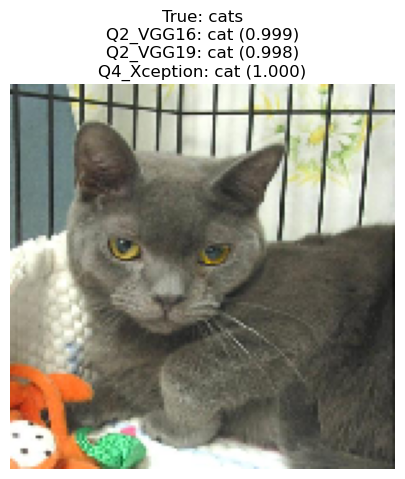

In [103]:
candidate_runs = [
    ('Q2_VGG16', q2_vgg16),
    ('Q2_VGG19', q2_vgg19),
    ('Q4_Xception', q4_xception),
]
# best_name, best_run = sorted(candidate_runs, key=lambda x: x[1]['final_test_acc'], reverse=True)[0]
# best_model = best_run['model_obj']

all_test_images = []
for cls in ['cats', 'dogs']:
    cls_dir = test_dir / cls
    all_test_images.extend([(p, cls) for p in cls_dir.iterdir() if p.is_file()])

img_path, true_label = random.choice(all_test_images)
img = keras_image.load_img(str(img_path), target_size=IMG_SIZE)
img_arr = keras_image.img_to_array(img) / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

img_path, true_label = random.choice(all_test_images)
img = keras_image.load_img(str(img_path), target_size=IMG_SIZE)
img_arr = keras_image.img_to_array(img) / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

pred_lines = []
print('Example image path:', img_path)
print('True label:', true_label)

for model_name, run in candidate_runs:
    model = run['model_obj']
    pred_score = float(model.predict(img_arr, verbose=0)[0][0])  # dog probability
    pred_label = 'dog' if pred_score >= 0.5 else 'cat'
    confidence = pred_score if pred_label == 'dog' else (1 - pred_score)
    pred_lines.append(f'{model_name}: {pred_label} ({confidence:.3f})')
    print(f'{model_name} -> pred: {pred_label}, dog_prob: {pred_score:.4f}, conf: {confidence:.4f}')

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.title(
    f"True: {true_label}\n" + "\n".join(pred_lines)
)
plt.axis('off')
plt.show()

## Insights

In [104]:
summary = {
    'q1': q1_df.drop(columns=['history', 'model_obj'], errors='ignore').to_dict(orient='records'),
    'q2': q2_df.drop(columns=['history', 'model_obj'], errors='ignore').to_dict(orient='records'),
    'q3': q3_df.to_dict(orient='records'),
    'q4': {
        'xception': {k: v for k, v in q4_xception.items() if k not in ['history', 'model_obj']},
        'comparison_table': q4_compare.to_dict(orient='records'),
    },
    'dataset_split_note': split_note,
}

summary_json = OUTPUT_DIR / 'Group8_ANN_Lab3_summary.json'
with open(summary_json, 'w', encoding='utf-8') as f:
    import json
    json.dump(summary, f, indent=2)

q1_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q1_table.csv'
q2_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q2_table.csv'
q3_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q3_table.csv'
q4_csv = OUTPUT_DIR / 'Group8_ANN_Lab3_q4_table.csv'

q1_df.drop(columns=['history', 'model_obj'], errors='ignore').to_csv(q1_csv, index=False)
q2_df.drop(columns=['history', 'model_obj'], errors='ignore').to_csv(q2_csv, index=False)
q3_df.to_csv(q3_csv, index=False)
q4_compare.to_csv(q4_csv, index=False)

q1_best = q1_df.sort_values('final_test_acc', ascending=False).iloc[0]
q2_best = q2_df.sort_values('final_test_acc', ascending=False).iloc[0]
q3_best = q3_df.sort_values('final_test_acc', ascending=False).iloc[0]
q4_best = q4_compare.sort_values('final_test_acc', ascending=False).iloc[0]

q3_sorted = q3_df.sort_values('samples_per_epoch_target').reset_index(drop=True)
q3_sorted['delta_test_acc'] = q3_sorted['final_test_acc'].diff()

p1 = (
    f"For ImageDataGenerator tuning, the stronger result came from **{q1_best['model_name']}** "
    f"with test accuracy **{q1_best['final_test_acc']:.4f}**, showing that on this split, its augmentation intensity "
    f"struck a better balance between regularization and preserving recognizable cat/dog structure. "
    f"Both Q1 runs reached 30 epochs, and the accuracy-loss curves indicate stable convergence without severe divergence "
    f"between training and validation trajectories."
)

p2 = (
    f"In the VGG comparison, **{q2_best['backbone']}** achieved the higher test accuracy (**{q2_best['final_test_acc']:.4f}**). "
    f"Architecturally, VGG19 is deeper and has more parameters than VGG16, and in this run that additional capacity "
    f"translated to slightly better holdout performance. The paired train/validation loss and accuracy plots provide the "
    f"same training conditions across both backbones, so the gap is directly attributable to backbone behavior under the same pipeline."
)

p3 = (
    f"For the no-augmentation sample-budget experiment, the best observed point was **{int(q3_best['samples_per_epoch_target'])} samples/epoch** "
    f"with test accuracy **{q3_best['final_test_acc']:.4f}**. The per-run curves and marginal-delta table show non-monotonic gains, "
    f"which suggests diminishing returns and instability when repeatedly cycling limited unique images without augmentation. "
    f"Q3 logs were run in silent mode (`verbose=0`) to reduce PDF clutter while keeping full metric outputs and plots."
)

p4 = (
    f"In the final architecture comparison, **{q4_best['backbone']}** was best overall with test accuracy "
    f"**{q4_best['final_test_acc']:.4f}**. Relative to the best VGG result, Xception benefited from depthwise-separable convolution blocks "
    f"and more efficient feature extraction. The final recommendation for this notebook is therefore Xception for best predictive performance, "
    f"with Q1/Q2/Q3 retained as ablation evidence and comparative analysis."
)

display(Markdown(p1 + '\n\n' + p2 + '\n\n' + p3 + '\n\n' + p4))

print('Saved summary JSON:', summary_json)
print('Saved tables:')
print(' -', q1_csv)
print(' -', q2_csv)
print(' -', q3_csv)
print(' -', q4_csv)
print('\nQ3 marginal gains table:')
display(q3_sorted[['samples_per_epoch_target', 'final_test_acc', 'delta_test_acc']])

For ImageDataGenerator tuning, the stronger result came from **Q1_VGG16_default_aug** with test accuracy **0.9000**, showing that on this split, its augmentation intensity struck a better balance between regularization and preserving recognizable cat/dog structure. Both Q1 runs reached 30 epochs, and the accuracy-loss curves indicate stable convergence without severe divergence between training and validation trajectories.

In the VGG comparison, **VGG19** achieved the higher test accuracy (**0.9100**). Architecturally, VGG19 is deeper and has more parameters than VGG16, and in this run that additional capacity translated to slightly better holdout performance. The paired train/validation loss and accuracy plots provide the same training conditions across both backbones, so the gap is directly attributable to backbone behavior under the same pipeline.

For the no-augmentation sample-budget experiment, the best observed point was **2000 samples/epoch** with test accuracy **0.9020**. The per-run curves and marginal-delta table show non-monotonic gains, which suggests diminishing returns and instability when repeatedly cycling limited unique images without augmentation. Q3 logs were run in silent mode (`verbose=0`) to reduce PDF clutter while keeping full metric outputs and plots.

In the final architecture comparison, **Xception** was best overall with test accuracy **0.9640**. Relative to the best VGG result, Xception benefited from depthwise-separable convolution blocks and more efficient feature extraction. The final recommendation for this notebook is therefore Xception for best predictive performance, with Q1/Q2/Q3 retained as ablation evidence and comparative analysis.

Saved summary JSON: /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_summary.json
Saved tables:
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q1_table.csv
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q2_table.csv
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q3_table.csv
 - /home/solyvie/workspace/cs-projects/25263CSDMachineLearning/[7] Group 8 - Module 6 CNN Part 3 - Using Pre-Trained Networks/models/Group8_ANN_Lab3_q4_table.csv

Q3 marginal gains table:


,samples_per_epoch_target,final_test_acc,delta_test_acc
0,500,0.888,NaN
1,1000,0.896,0.008
2,2000,0.902,0.006
3,5000,0.898,-0.004
4,10000,0.900,0.002
5,15000,0.890,-0.010
